# Applied Statistics for Data Science with Python


# Chapter 6: Sampling Designs & Experiments

by Gal Arav M.Sc. © 2026  
Licensed under the MIT LICENSE  

<a href="https://qikly.com/?utm_source=colab&utm_medium=notebook&utm_campaign=colab_referral" target="_blank">qikly.com</a>

## Learning Objectives  

This notebook accompanies the book's Chapter 6 with these objectives:

- Compare common sampling designs and assess representativeness
- Use standardized differences and weights to evaluate sample quality
- Apply stratified resampling for reliable model evaluation
- Understand treatment assignment and randomization in experiments
- Interpret effect sizes for A/B tests with different outcome types
- Estimate statistical power through simulation and relate it to effect size and sample size






In [ ]:
# Utility function to save a high‑resolution figure for the textbook
# Images are saved temporarily in Google Colab and disappear when the session ends
import matplotlib.pyplot as plt
import os

def export_plot(fig, plot_id, dpi=300, width=8, height=5, outdir="exports"):
    fig.set_size_inches(width, height)
    fig.subplots_adjust(left=0.12, right=0.95, top=0.87, bottom=0.15)
    os.makedirs(outdir, exist_ok=True)
    fig.savefig(f"{outdir}/{plot_id}.png", dpi=dpi, bbox_inches=None, pad_inches=0.45)

## Simulation Data

In [ ]:
# ============================================================
# Setup and canonical dataset
# ============================================================

# This setup block constructs a synthetic population that we will repeatedly sample from.

# Prepare environment, set a reproducible seed, and create a single canonical synthetic dataset
# that will be reused for demonstrations.

# The dataset contains a skewed numeric outcome, a categorical
# stratum "group", a time column, and a binary label for demonstration.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold

N = 10000

SEED = 42
np.random.seed(SEED)
sns.set(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4)})

# Generate an hourly timestamp column to mimic a real dataset with temporal structure.
time = pd.date_range("2020-01-01", periods=N, freq="h")

# Create a categorical subgroup variable with intentionally imbalanced probabilities.
# This gives us realistic strata for later demonstrations of stratified sampling,
# representativeness checks, and subgroup-specific diagnostics.
group = np.random.choice(
    ["A", "B", "C", "D"],
    size=N,
    p=[0.6, 0.2, 0.15, 0.05]   # strong imbalance is intentional
)

# Generate a skewed numeric outcome using a lognormal distribution.
# The heavy right tail makes CLT demonstrations, bootstrap intervals,
# and power simulations more visually meaningful.
outcome = np.random.lognormal(mean=1.0, sigma=1.0, size=N)

# Assemble the dataset.
df = pd.DataFrame({
    "time": time,
    "group": group,
    "outcome": outcome
})

# Population outcome values and size N
pop = df["outcome"].values

# Create a binary label marking the top quartile of the outcome distribution.
# This mimics a classification target and allows later sections to show how
# labels interact with sampling strategies and evaluation design.
df["label"] = (df["outcome"] > np.percentile(df["outcome"], 75)).astype(int)

print("Dataset preview:")
print(df.head().to_string(index=False))

print("\nGroup proportions (population):")
print(df["group"].value_counts(normalize=True).sort_index())

Dataset preview:
               time group  outcome  label
2020-01-01 00:00:00     A 0.613938      0
2020-01-01 01:00:00     D 0.882333      0
2020-01-01 02:00:00     B 4.010111      0
2020-01-01 03:00:00     A 0.840403      0
2020-01-01 04:00:00     A 8.269998      1

Group proportions (population):
group
A    0.6108
B    0.1930
C    0.1488
D    0.0474
Name: proportion, dtype: float64


### Simulated Population Data Generation

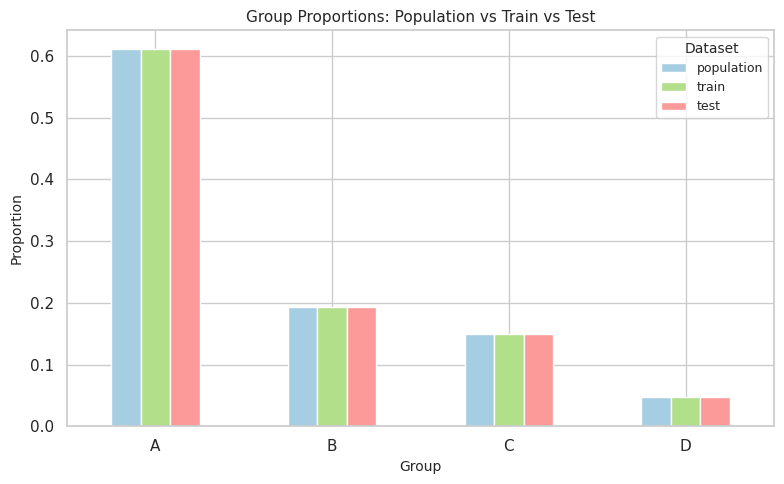

In [ ]:
# ============================================================
# Stratified sampling and representativeness checks
# ============================================================

# Create an 80/20 stratified split by 'group' to preserve subgroup proportions.
train = df.groupby("group", group_keys=False).sample(frac=0.8, random_state=SEED)
test = df.drop(train.index)

# Compute group proportions in population, train, and test sets.
prop_pop = df["group"].value_counts(normalize=True).sort_index()
prop_train = train["group"].value_counts(normalize=True).sort_index()
prop_test = test["group"].value_counts(normalize=True).sort_index()
prop_df = pd.DataFrame({"population": prop_pop, "train": prop_train, "test": prop_test})

# Plot subgroup proportion comparison to visually confirm stratification worked.
ax = prop_df.plot(
    kind="bar",
    rot=0,
    title="Group Proportions: Population vs Train vs Test",
    figsize=(8,5),
    color=["#a6cee3", "#b2df8a", "#fb9a99"]  # pastel colors
)
ax.set_xlabel("Group", fontsize=10)
ax.set_ylabel("Proportion", fontsize=10)
ax.set_title("Group Proportions: Population vs Train vs Test", fontsize=11)
plt.legend(title="Dataset", fontsize=9, title_fontsize=10)
plt.tight_layout()
fig = plt.gcf()
plt.show()
export_plot(fig, "sim_stratified_group_proportions")

## Sampling Designs & Representativeness

### Stratified sampling and representativeness checks

Group A: standardized difference (test vs population) = 0.018
Group B: standardized difference (test vs population) = -0.144
Group C: standardized difference (test vs population) = 0.013
Group D: standardized difference (test vs population) = -0.040


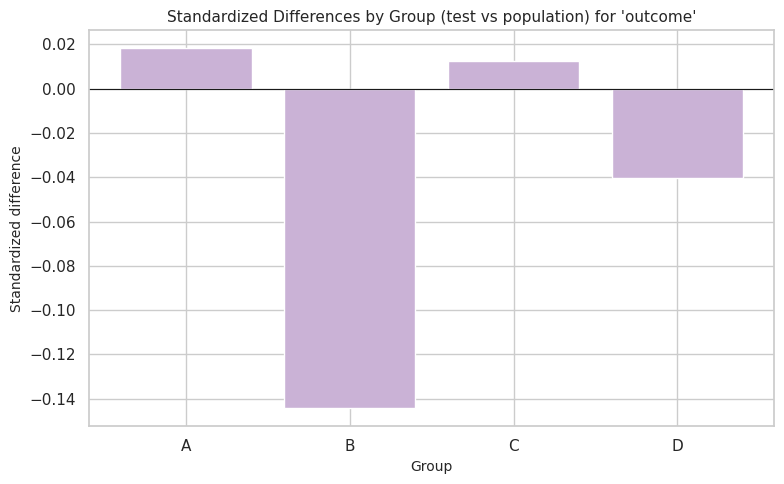

In [ ]:
# ============================================================
# Stratified sampling and representativeness checks
# ============================================================

# Function to compute standardized differences between population and sample
# for a continuous variable. Values near 0 indicate good balance.
def std_diff(pop_series, sample_series):
    mu_pop = pop_series.mean()
    mu_s = sample_series.mean()
    s_pooled = np.sqrt((pop_series.var(ddof=1) + sample_series.var(ddof=1)) / 2)
    return (mu_s - mu_pop) / s_pooled

# Compute standardized differences for each group to assess representativeness
# of the test set with respect to the population on the 'outcome' variable.
groups = sorted(df["group"].unique())
std_diffs = []
for g in groups:
    pop_g = df.loc[df["group"] == g, "outcome"]
    test_g = test.loc[test["group"] == g, "outcome"]
    sd = std_diff(pop_g, test_g)
    std_diffs.append(sd)
    print(f"Group {g}: standardized difference (test vs population) = {sd:.3f}")

# Plot standardized differences to identify any imbalance across groups.
plt.figure(figsize=(8,5))
plt.bar(groups, std_diffs, color="#cab2d6")  # pastel purple
plt.axhline(0, color="k", linewidth=0.8)
plt.title("Standardized Differences by Group (test vs population) for 'outcome'", fontsize=11)
plt.xlabel("Group", fontsize=10)
plt.ylabel("Standardized difference", fontsize=10)
plt.tight_layout()

fig = plt.gcf()
plt.show()
export_plot(fig, "sim_stratified_sd_group_for_outcome")


### Group proportion preservation with StratifiedKFold

In [ ]:
# ============================================================
# Group proportion preservation with StratifiedKFold
# ============================================================

# StratifiedKFold maintains group proportions across folds.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Use 'group' as the stratification label to show fold-level balance.
for fold, (train_idx, val_idx) in enumerate(skf.split(df, df["group"])):
    val_props = df.iloc[val_idx]["group"].value_counts(normalize=True).sort_index()
    print(f"Fold {fold} validation group proportions:\n{val_props.to_dict()}")

Fold 0 validation group proportions:
{'A': 0.611, 'B': 0.193, 'C': 0.1485, 'D': 0.0475}
Fold 1 validation group proportions:
{'A': 0.611, 'B': 0.193, 'C': 0.1485, 'D': 0.0475}
Fold 2 validation group proportions:
{'A': 0.611, 'B': 0.193, 'C': 0.149, 'D': 0.047}
Fold 3 validation group proportions:
{'A': 0.6105, 'B': 0.193, 'C': 0.149, 'D': 0.0475}
Fold 4 validation group proportions:
{'A': 0.6105, 'B': 0.193, 'C': 0.149, 'D': 0.0475}


### Distribution Matching with Standardized Mean Differences


Distribution Matching (SMD) across folds:
Fold 0: feature_x SMD = -0.007
Fold 1: feature_x SMD = 0.003
Fold 2: feature_x SMD = -0.010
Fold 3: feature_x SMD = 0.027
Fold 4: feature_x SMD = -0.013


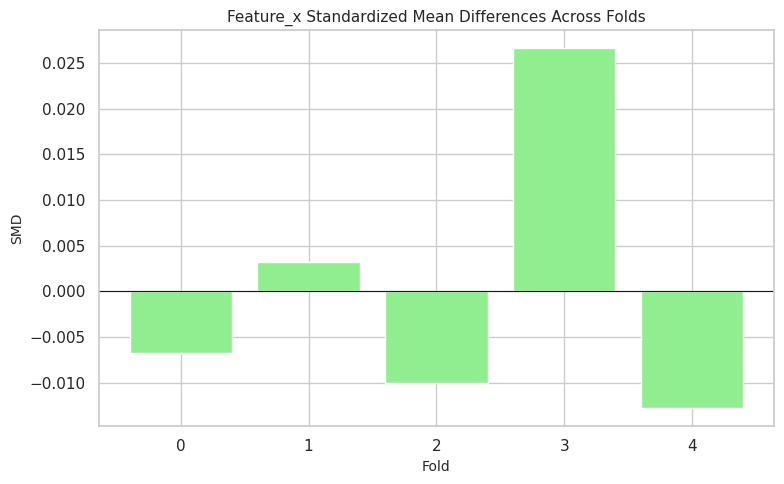

In [ ]:
# ============================================================
# Distribution Matching with Standardized Mean Differences
# ============================================================

# To illustrate distribution matching correctly, we introduce a continuous
# predictor variable that is independent of the outcome. Using the outcome
# itself would conflate predictors with the target, which is not good
# practice in real modeling workflows. A simple Gaussian predictor serves
# as a neutral feature whose distribution we can check across folds.

# Ensure deterministic behavior
import random
np.random.seed(SEED)
random.seed(SEED)

# Add a proper continuous predictor for distribution matching
df["feature_x"] = np.random.normal(loc=0, scale=1, size=N)

# StratifiedKFold with deterministic shuffling
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def smd(pop_series, fold_series):
    mu_pop = pop_series.mean()
    mu_fold = fold_series.mean()
    s_pooled = np.sqrt((pop_series.var(ddof=1) + fold_series.var(ddof=1)) / 2)
    return (mu_fold - mu_pop) / s_pooled

print("\nDistribution Matching (SMD) across folds:")

smd_values = []

for fold, (_, val_idx) in enumerate(skf.split(df, df["group"])):
    val_df = df.iloc[val_idx]
    sd = smd(df["feature_x"], val_df["feature_x"])
    smd_values.append(sd)
    print(f"Fold {fold}: feature_x SMD = {sd:.3f}")

# Plot SMD values across folds to visualize distributional balance.
plt.figure(figsize=(8,5))
plt.bar(range(len(smd_values)), smd_values, color="#90ee90")  # pastel green
plt.axhline(0, color="k", linewidth=0.8)
plt.title("Feature_x Standardized Mean Differences Across Folds", fontsize=11)
plt.xlabel("Fold", fontsize=10)
plt.ylabel("SMD", fontsize=10)
plt.tight_layout()

fig = plt.gcf()
plt.show()
export_plot(fig, "sim_stratified_sd_distribution_matching")

### Target Leakage Demonstration


In [ ]:
# ============================================================
# Target Leakage Demonstration
# ============================================================

# A Simple Example of Target Leakage
# Here we create a "feature" that is actually derived from the outcome.
# It looks like a legitimate continuous predictor, but it is mathematically
# tied to the target and therefore leaks privileged information.

df["leaky_feature"] = np.log(df["outcome"] + 1e-6)  # avoid log(0)

# If we now perform a stratified split, the leakage persists across folds
# because the leaky feature is present in both training and validation sets.

train_idx, test_idx = next(skf.split(df, df["group"]))
train_df = df.iloc[train_idx]
test_df  = df.iloc[test_idx]

# Check correlation to reveal the leakage
corr_train = train_df[["outcome", "leaky_feature"]].corr().iloc[0,1]
corr_test  = test_df[["outcome", "leaky_feature"]].corr().iloc[0,1]

print("Correlation between outcome and leaky_feature:")
print(f"  Train fold: {corr_train:.3f}")
print(f"  Test fold : {corr_test:.3f}")

Correlation between outcome and leaky_feature:
  Train fold: 0.730
  Test fold : 0.785


## A/B Testing, Power and Effect Sizes


### A/B Testing and Power Analysis


A/B Test Example (top of notebook):
Welch t-test: t = -2.982, p = 0.0030
Group A mean = 3.8088, Group B mean = 4.6247


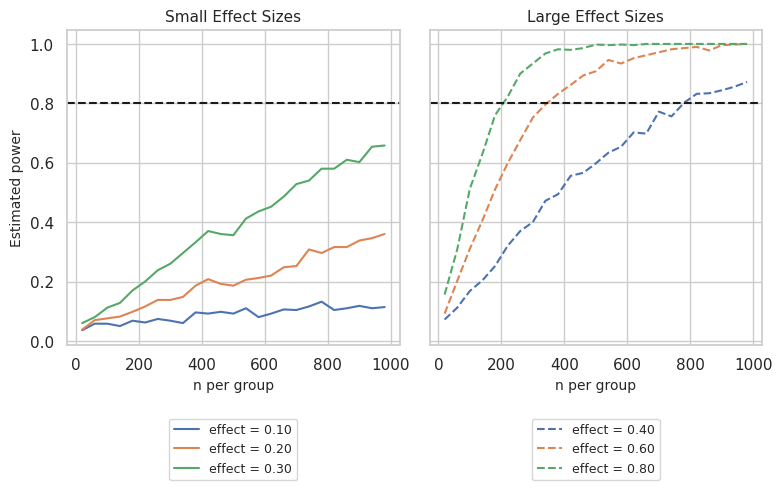


--- Small Effect Sizes (left-hand chart) ---
Effect 0.10: Even at n = 980 per group, estimated power remained below 0.80
Effect 0.20: Even at n = 980 per group, estimated power remained below 0.80
Effect 0.30: Even at n = 980 per group, estimated power remained below 0.80

--- Large Effect Sizes (right-hand chart) ---
Effect 0.40: n_per ≈ 780 needed for 0.80 power
Effect 0.60: n_per ≈ 380 needed for 0.80 power
Effect 0.80: n_per ≈ 220 needed for 0.80 power


In [ ]:
# ============================================================
# A/B testing and power analysis (analytic + simulation)
#
# Basic simulation setup:
# We begin by constructing a synthetic population drawn from a
# skewed gamma distribution to mimic realistic, heterogeneous
# user‑level data. Two samples are then drawn from this population
# to illustrate a simple A/B test: group A represents a baseline
# version of a system, while group B represents an alternative
# version with a small mean shift added to simulate an effect.
# A Welch two‑sample t‑test is used to assess whether the groups
# differ in their mean outcomes. The remainder of the cell performs
# fast, vectorized simulation‑based power analysis for both small
# and large effect sizes.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

SEED = 123
rng = np.random.default_rng(SEED)

# ------------------------------------------------------------
# Construct population and run a simple A/B test
# ------------------------------------------------------------
pop = rng.gamma(shape=2.0, scale=2.0, size=200_000)

n_per = 200
A = rng.choice(pop, size=n_per, replace=False)
B = rng.choice(pop, size=n_per, replace=False) + 0.5

tstat, pval = stats.ttest_ind(A, B, equal_var=False)
print("\nA/B Test Example (top of notebook):")
print(f"Welch t-test: t = {tstat:.3f}, p = {pval:.4f}")
print(f"Group A mean = {A.mean():.4f}, Group B mean = {B.mean():.4f}")

# ------------------------------------------------------------
# Fast vectorized power estimator
# ------------------------------------------------------------
def estimate_power_fast(effect, n_per, n_sims=500, alpha=0.05, random_state=None):
    rng = np.random.default_rng(random_state)

    mu = np.mean(pop)
    sd = np.std(pop, ddof=1)

    A = rng.normal(mu, sd, size=(n_sims, n_per))
    B = rng.normal(mu + effect, sd, size=(n_sims, n_per))

    meanA = A.mean(axis=1)
    meanB = B.mean(axis=1)
    varA = A.var(axis=1, ddof=1)
    varB = B.var(axis=1, ddof=1)

    tstats = (meanA - meanB) / np.sqrt(varA/n_per + varB/n_per)

    df = (varA/n_per + varB/n_per)**2 / (
        (varA/n_per)**2/(n_per-1) + (varB/n_per)**2/(n_per-1)
    )

    pvals = 2 * stats.t.sf(np.abs(tstats), df)
    return np.mean(pvals < alpha)

# ------------------------------------------------------------
# Power curves for small and large effects
# ------------------------------------------------------------
n_grid = np.arange(20, 1001, 40)

small_effects = [0.1, 0.2, 0.3]
large_effects = [0.4, 0.6, 0.8]   # smaller than before → cross later

power_small = {eff: [] for eff in small_effects}
power_large = {eff: [] for eff in large_effects}

for eff in small_effects:
    for n_try in n_grid:
        pwr = estimate_power_fast(eff, int(n_try), n_sims=500, random_state=SEED)
        power_small[eff].append(pwr)

for eff in large_effects:
    for n_try in n_grid:
        pwr = estimate_power_fast(eff, int(n_try), n_sims=500, random_state=SEED)
        power_large[eff].append(pwr)

# ------------------------------------------------------------
# Two side-by-side charts (8x5 total), legends underneath
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

# Left: small effects
for eff in small_effects:
    axes[0].plot(n_grid, power_small[eff], label=f"effect = {eff:.2f}")
axes[0].axhline(0.8, color="k", linestyle="--")
axes[0].set_title("Small Effect Sizes", fontsize=11)
axes[0].set_xlabel("n per group", fontsize=10)
axes[0].set_ylabel("Estimated power", fontsize=10)
axes[0].legend(loc="lower center", bbox_to_anchor=(0.5, -0.45), fontsize=9)

# Right: large effects
for eff in large_effects:
    axes[1].plot(n_grid, power_large[eff], linestyle="--", label=f"effect = {eff:.2f}")
axes[1].axhline(0.8, color="k", linestyle="--")
axes[1].set_title("Large Effect Sizes", fontsize=11)
axes[1].set_xlabel("n per group", fontsize=10)
axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, -0.45), fontsize=9)

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()

fig = plt.gcf()
plt.show()
export_plot(fig, "sim_power_curves")


# ------------------------------------------------------------
# Print sample sizes needed for 80% power
# ------------------------------------------------------------
print("\n--- Small Effect Sizes (left-hand chart) ---")
for eff in small_effects:
    try:
        idx = next(i for i, p in enumerate(power_small[eff]) if p >= 0.8)
        print(f"Effect {eff:.2f}: n_per ≈ {n_grid[idx]} needed for 0.80 power")
    except StopIteration:
        print(f"Effect {eff:.2f}: Even at n = {n_grid[-1]} per group, estimated power remained below 0.80")

print("\n--- Large Effect Sizes (right-hand chart) ---")
for eff in large_effects:
    idx = next(i for i, p in enumerate(power_large[eff]) if p >= 0.8)
    print(f"Effect {eff:.2f}: n_per ≈ {n_grid[idx]} needed for 0.80 power")

### Covariate Balance Diagnostics: SMDs

Average absolute SMD by scheme and covariate:
Covariate     age  prior_activity
Scheme                           
Blocked     0.168           0.004
Simple      0.210           0.205
Stratified  0.083           0.173

Proportion of runs with |SMD| > 0.1:
Covariate     age  prior_activity
Scheme                           
Blocked     0.633           0.000
Simple      0.686           0.688
Stratified  0.325           0.641


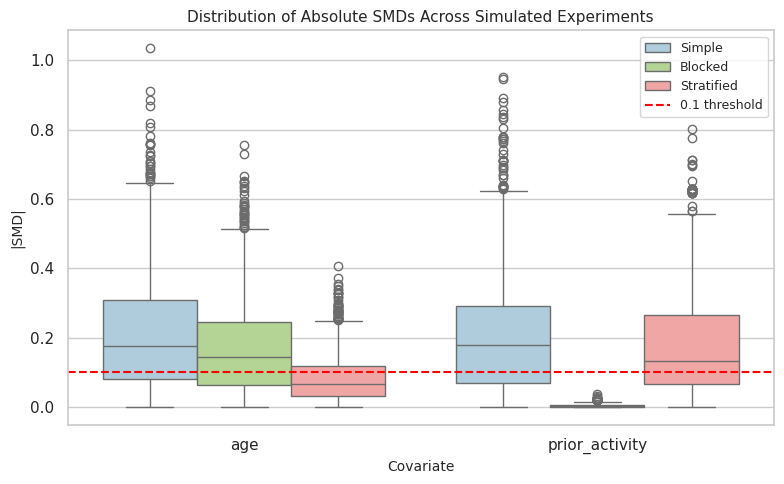

In [ ]:
# ============================================================
# Covariate Balance Diagnostics: SMDs (simple vs blocked vs stratified)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
np.random.seed(42)

# 1. Simulation settings
N = 60          # small experiment size
R = 2000        # number of simulated experiments

def smd(x_treat, x_control):
    mean_t = np.mean(x_treat)
    mean_c = np.mean(x_control)
    sd_pooled = np.sqrt((np.var(x_treat, ddof=1) + np.var(x_control, ddof=1)) / 2)
    return (mean_t - mean_c) / sd_pooled if sd_pooled != 0 else 0

def one_experiment(N):
    # Heterogeneous population: two subgroups with very different covariates
    group = np.random.binomial(1, 0.5, size=N)
    age = np.where(group == 0,
                   np.random.normal(25, 5, size=N),
                   np.random.normal(55, 5, size=N))
    prior_activity = np.where(group == 0,
                              np.random.binomial(1, 0.2, size=N),
                              np.random.binomial(1, 0.8, size=N))

    df = pd.DataFrame({
        "age": age,
        "prior_activity": prior_activity
    })

    # --- Simple randomization ---
    df["treat_simple"] = np.random.binomial(1, 0.5, size=N)

    # --- Blocked randomization on prior_activity ---
    df["treat_blocked"] = 0
    for v in [0, 1]:
        idx = df.index[df["prior_activity"] == v].to_numpy()
        if len(idx) > 0:
            k = len(idx) // 2
            treated_idx = np.random.choice(idx, size=k, replace=False)
            df.loc[treated_idx, "treat_blocked"] = 1

    # --- Stratified randomization on age_group (median split) ---
    df["age_group"] = (df["age"] > np.median(df["age"])).astype(int)
    df["treat_stratified"] = 0
    for v in [0, 1]:
        idx = df.index[df["age_group"] == v].to_numpy()
        if len(idx) > 0:
            k = len(idx) // 2
            treated_idx = np.random.choice(idx, size=k, replace=False)
            df.loc[treated_idx, "treat_stratified"] = 1

    # Compute SMDs for each scheme and covariate
    results = []
    for scheme in ["treat_simple", "treat_blocked", "treat_stratified"]:
        for cov in ["age", "prior_activity"]:
            t = df[df[scheme] == 1][cov]
            c = df[df[scheme] == 0][cov]
            results.append({
                "Scheme": scheme.replace("treat_", "").capitalize(),
                "Covariate": cov,
                "SMD": smd(t, c)
            })
    return results

# 2. Run many experiments
all_results = []
for _ in range(R):
    all_results.extend(one_experiment(N))

smd_df = pd.DataFrame(all_results)
smd_df["abs_SMD"] = smd_df["SMD"].abs()

# 3. Numeric summary: average |SMD| and % with |SMD| > 0.1
summary_mean = (
    smd_df.groupby(["Scheme", "Covariate"])["abs_SMD"]
          .mean()
          .unstack()
          .round(3)
)

summary_prop = (
    (smd_df["abs_SMD"] > 0.1)
    .groupby([smd_df["Scheme"], smd_df["Covariate"]])
    .mean()
    .unstack()
    .round(3)
)

print("Average absolute SMD by scheme and covariate:")
print(summary_mean)
print("\nProportion of runs with |SMD| > 0.1:")
print(summary_prop)

# 4. Plot distribution of absolute SMDs
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=smd_df,
    x="Covariate",
    y="abs_SMD",
    hue="Scheme",
    palette=["#a6cee3", "#b2df8a", "#fb9a99"]  # pastel blue, green, red
)
plt.axhline(0.1, color="red", linestyle="--", label="0.1 threshold")
plt.title("Distribution of Absolute SMDs Across Simulated Experiments", fontsize=11)
plt.xlabel("Covariate", fontsize=10)
plt.ylabel("|SMD|", fontsize=10)
plt.legend(fontsize=9, title_fontsize=10)
plt.tight_layout()

fig = plt.gcf()
plt.show()
export_plot(fig, "sim_covariate_balance_diagnostics_using_smds")